# MILP Optimization Comparison

Compare all available experiment outputs: ABCROWN, MILP with stable ReLU binary fixing, and MILP with no stable ReLU binary fixing.

The notebook reads artifacts generated by recreate.sh or uploaded from fixing-binary-vars-experiment. It does not rerun any benchmark.

In [1]:
from pathlib import Path
import json
import re

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 60)

In [2]:
def find_data_dir():
    candidates = [
        Path.cwd() / 'fixing-binary-vars-experiment',
        Path('/kaggle/input/fixing-binary-vars-experiment'),
        Path('/kaggle/working/fixing-binary-vars-experiment'),
    ]
    for candidate in candidates:
        if candidate.exists() and list(candidate.glob('*.csv')):
            return candidate
    kaggle_root = Path('/kaggle/input')
    if kaggle_root.exists():
        matches = list(kaggle_root.glob('**/fix-3-100-3pixel.csv'))
        if matches:
            return matches[0].parent
    raise FileNotFoundError('Could not find fixing-binary-vars-experiment.')

DATA_DIR = find_data_dir()
print(f'Using data from: {DATA_DIR}')
sorted(path.name for path in DATA_DIR.glob('*'))

Using data from: /kaggle/input/datasets/mohhbrr/fixing-binary-vars-experiment/fixing-binary-vars-experiment


['fix-2-512-3pixel.csv',
 'fix-2-512-3pixel.json',
 'fix-3-100-3pixel.csv',
 'fix-3-100-3pixel.json',
 'fix-3-100-global.csv',
 'fix-3-100-global.json',
 'fix-4-1024-3pixel.csv',
 'fix-4-1024-3pixel.json',
 'no-fix-2-512-3pixel.csv',
 'no-fix-2-512-3pixel.json',
 'no-fix-3-100-3pixel.csv',
 'no-fix-3-100-3pixel.json',
 'no-fix-3-100-global.csv',
 'no-fix-3-100-global.json',
 'no-fix-4-1024-3pixel.csv',
 'no-fix-4-1024-3pixel.json',
 'recreate.sh']

In [3]:
def load_milp_csv(path):
    stem = path.stem
    configuration = (
        'MILP (stable-binary fixing)'
        if stem.startswith('fix-')
        else 'MILP (no stable-binary fixing)'
    )
    experiment = re.sub(r'^(fix|no-fix)-', '', stem)
    csv = pd.read_csv(path)
    csv['optimizer'] = 'MILP'
    csv['configuration'] = configuration
    csv['experiment'] = experiment
    csv['source_file'] = path.name
    return csv

def load_crown_csv(path):
    stem = path.stem
    match = re.match(r'crown-(.+)-([^-]+)$', stem)
    experiment = match.group(1) if match else stem.removeprefix('crown-')
    profile = match.group(2) if match else 'unknown'
    csv = pd.read_csv(path)
    csv['optimizer'] = 'ABCROWN'
    csv['configuration'] = f'ABCROWN ({profile})'
    csv['experiment'] = experiment
    csv['source_file'] = path.name
    csv['solver_status'] = csv.get('abcrown_status', csv.get('status'))
    return csv

tables = []
for path in sorted(DATA_DIR.glob('*.csv')):
    if path.name.startswith('crown-'):
        tables.append(load_crown_csv(path))
    elif path.name.startswith(('fix-', 'no-fix-')):
        tables.append(load_milp_csv(path))

results = pd.concat(tables, ignore_index=True)
results['solver_status'] = results.get('solver_status', results['status'])
experiment_order = [
    f'{network}-{region}'
    for region in ('3pixel', 'global')
    for network in ('3-100', '2-512', '4-1024')
]
results['experiment'] = pd.Categorical(
    results['experiment'], categories=experiment_order, ordered=True
)
results[['optimizer', 'configuration', 'experiment', 'status']].head()

,optimizer,configuration,experiment,status
0,MILP,MILP (fixed stable binaries),2-512-3pixel,unsat
1,MILP,MILP (fixed stable binaries),2-512-3pixel,unsat
2,MILP,MILP (fixed stable binaries),2-512-3pixel,unknown
3,MILP,MILP (fixed stable binaries),2-512-3pixel,unsat
4,MILP,MILP (fixed stable binaries),2-512-3pixel,unsat


In [4]:
def load_milp_debug():
    rows = []
    for path in sorted(DATA_DIR.glob('*.json')):
        if not path.name.startswith(('fix-', 'no-fix-')):
            continue
        configuration = (
            'MILP (stable-binary fixing)'
            if path.name.startswith('fix-')
            else 'MILP (no stable-binary fixing)'
        )
        experiment = re.sub(r'^(fix|no-fix)-|\.json$', '', path.name)
        for record in json.loads(path.read_text()):
            for direction, details in record.get('directions', {}).items():
                total = details.get('total', {})
                before = details.get('before_presolve', {})
                after = details.get('after_presolve', {})
                progress = details.get('cplex_progress', {})
                rows.append({
                    'optimizer': 'MILP',
                    'configuration': configuration,
                    'experiment': experiment,
                    'instance_id': record['instance_id'],
                    'direction': direction,
                    'binary_variables_before_presolve': total.get('unfixed_binary_variables', before.get('unfixed_binary_variables')),
                    'after_binary_variables': after.get('binary_variables', after.get('all_binary_variables')),
                    'presolve_time_sec': after.get('time_sec', after.get('presolve_time_sec')),
                    'nodes_processed': progress.get('nodes_processed'),
                    'nodes_remaining': progress.get('nodes_remaining'),
                    'lp_iterations': progress.get('iterations'),
                })
    return pd.DataFrame(rows)

milp_debug = load_milp_debug()
milp_debug['experiment'] = pd.Categorical(
    milp_debug['experiment'], categories=experiment_order, ordered=True
)
milp_debug.head()

,optimizer,configuration,experiment,instance_id,direction,unfixed_before,after_binary_variables,presolve_time_sec,nodes_processed,nodes_remaining,lp_iterations
0,MILP,MILP (fixed stable binaries),2-512-3pixel,mnist_relu_2_512_three_pixel_0,nn1_minus_nn2,100,100,0.11,0,0,640
1,MILP,MILP (fixed stable binaries),2-512-3pixel,mnist_relu_2_512_three_pixel_0,nn2_minus_nn1,100,100,0.11,0,0,600
2,MILP,MILP (fixed stable binaries),2-512-3pixel,mnist_relu_2_512_three_pixel_1,nn1_minus_nn2,82,82,0.10,0,0,635
3,MILP,MILP (fixed stable binaries),2-512-3pixel,mnist_relu_2_512_three_pixel_1,nn2_minus_nn1,82,82,0.12,0,0,617
4,MILP,MILP (fixed stable binaries),2-512-3pixel,mnist_relu_2_512_three_pixel_2,nn1_minus_nn2,296,296,0.11,3074,1201,243651


## Runtime and verification outcome

In [7]:
summary = (results.groupby(['experiment', 'configuration'], observed=True)
           .agg(instances=('instance_id', 'nunique'),
                unsat=('status', lambda s: (s == 'unsat').sum()),
                unknown=('status', lambda s: (s == 'unknown').sum()),
                median_runtime_sec=('runtime_sec', 'median'),
                mean_runtime_sec=('runtime_sec', 'mean'),
                max_runtime_sec=('runtime_sec', 'max'))
           .reset_index())
summary.sort_values(['experiment', 'configuration'])

,experiment,configuration,instances,unsat,unknown,median_runtime_sec,mean_runtime_sec,max_runtime_sec
0,3-100-3pixel,MILP (fixed stable binaries),100,100,0,0.977064,1.185079,3.562281
1,3-100-3pixel,MILP (unfixed stable binaries),100,100,0,0.816889,0.856583,1.256593
2,2-512-3pixel,MILP (fixed stable binaries),100,99,1,9.069469,11.144470,127.661698
3,2-512-3pixel,MILP (unfixed stable binaries),100,99,1,9.224584,12.662520,127.668024
4,4-1024-3pixel,MILP (fixed stable binaries),100,100,0,98.629604,107.677553,484.445766
5,4-1024-3pixel,MILP (unfixed stable binaries),100,99,1,99.091326,106.323188,494.391471
6,3-100-global,MILP (fixed stable binaries),100,91,9,6.277228,22.060161,124.556902
7,3-100-global,MILP (unfixed stable binaries),100,90,10,6.885712,21.878087,125.255432


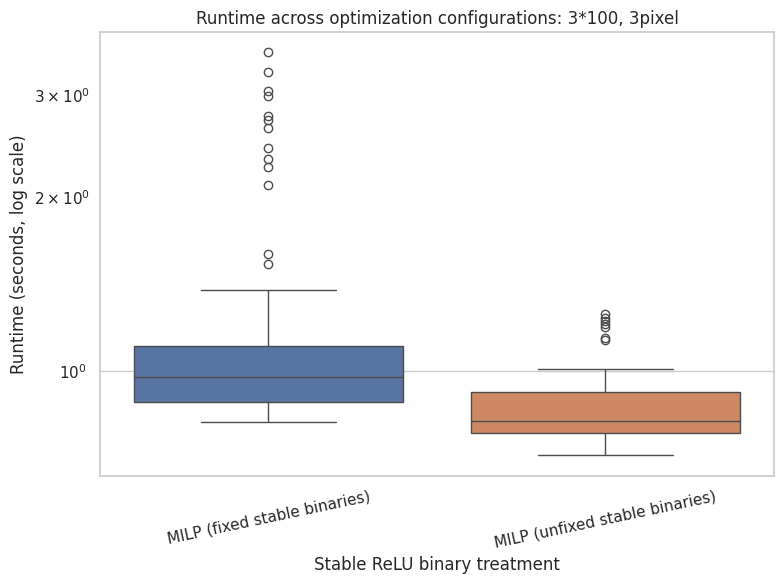

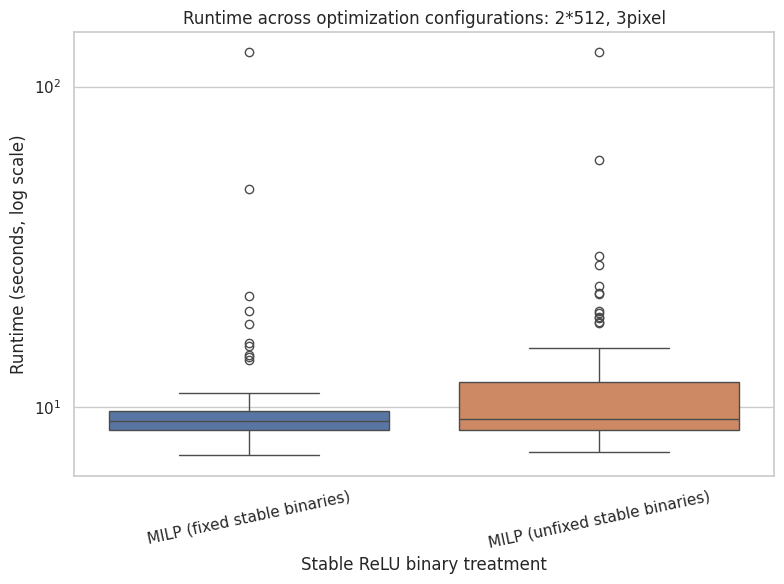

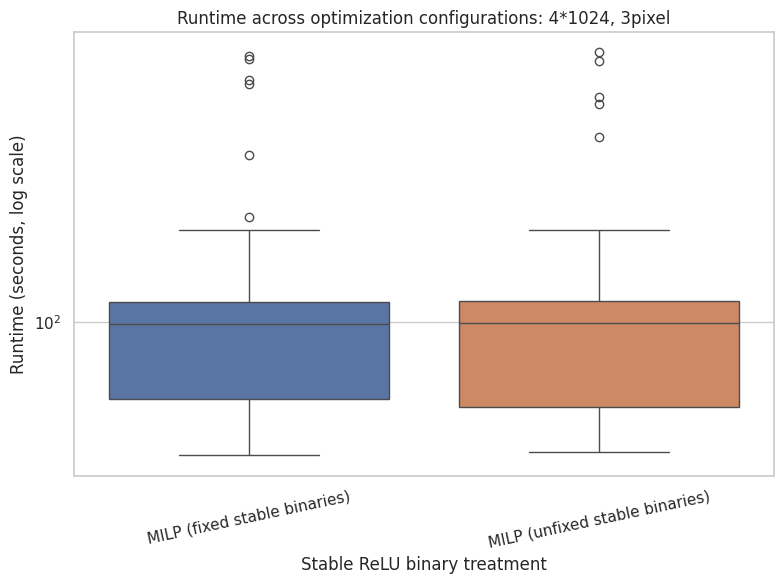

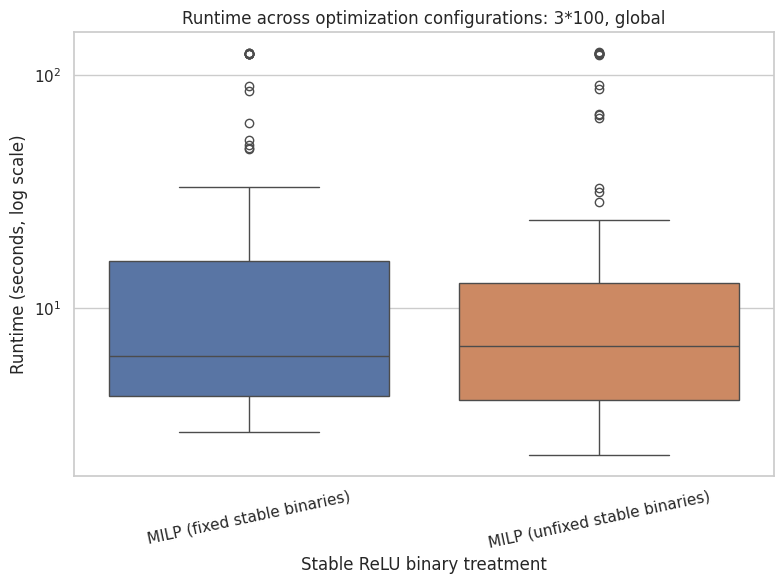

In [8]:
FIGURE_DIR = Path('/kaggle/working/figures')
if not FIGURE_DIR.parent.exists():
    FIGURE_DIR = Path('figures')
FIGURE_DIR.mkdir(exist_ok=True)

configuration_order = [
    'MILP (stable-binary fixing)',
    'MILP (no stable-binary fixing)',
]
for experiment in experiment_order:
    experiment_data = results[results['experiment'] == experiment]
    if experiment_data.empty:
        continue
    network, region = experiment.rsplit('-', maxsplit=1)
    network_label = network.replace('-', '*')
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.boxplot(
        data=experiment_data,
        x='configuration',
        y='runtime_sec',
        hue='configuration',
        order=configuration_order,
        hue_order=configuration_order,
        legend=False,
        ax=ax,
    )
    ax.set_yscale('log')
    ax.set_ylabel('Runtime (seconds, log scale)')
    ax.set_xlabel('Stable ReLU binary treatment')
    ax.tick_params(axis='x', labelrotation=12)
    ax.set_title(f'Runtime across optimization configurations: {network_label}, {region}')
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f'runtime-{experiment}.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)

## MILP search behavior

In [10]:
initial_binary_lookup = {}
for path in sorted(DATA_DIR.glob('no-fix-*.json')):
    experiment = re.sub(r'^no-fix-|\.json$', '', path.name)
    for record in json.loads(path.read_text()):
        for direction, details in record.get('directions', {}).items():
            total = details.get('total', {})
            before = details.get('before_presolve', {})
            initial_binary_lookup[(experiment, record['instance_id'], direction)] = total.get(
                'all_binary_variables', before.get('all_binary_variables')
            )

milp_summary = milp_debug.copy()
milp_summary['initial_binaries'] = [
    initial_binary_lookup.get((str(experiment), instance_id, direction))
    for experiment, instance_id, direction in zip(
        milp_summary['experiment'],
        milp_summary['instance_id'],
        milp_summary['direction'],
    )
]
numeric_metrics = ['initial_binaries', 'binary_variables_before_presolve', 'after_binary_variables', 'nodes_processed', 'lp_iterations', 'nodes_remaining']
milp_summary[numeric_metrics] = milp_summary[numeric_metrics].apply(
    pd.to_numeric, errors='coerce'
)
milp_summary.groupby(['experiment', 'configuration'], observed=True).agg(
    median_initial_binaries=('initial_binaries', 'median'),
    median_binary_variables_before_presolve=('binary_variables_before_presolve', 'median'),
    median_binaries_after_presolve=('after_binary_variables', 'median'),
).reset_index().sort_values(['experiment', 'configuration'])

,experiment,configuration,median_initial_binaries,median_unfixed_binaries_before_presolve,median_binaries_after_presolve
0,3-100-3pixel,MILP (fixed stable binaries),420.0,71.0,71.0
1,3-100-3pixel,MILP (unfixed stable binaries),420.0,420.0,71.0
2,2-512-3pixel,MILP (fixed stable binaries),2048.0,99.0,107.0
3,2-512-3pixel,MILP (unfixed stable binaries),2048.0,2048.0,107.0
4,4-1024-3pixel,MILP (fixed stable binaries),6164.0,355.0,376.0
5,4-1024-3pixel,MILP (unfixed stable binaries),6164.0,6164.0,376.0
6,3-100-global,MILP (fixed stable binaries),420.0,99.0,99.0
7,3-100-global,MILP (unfixed stable binaries),420.0,420.0,99.0


In [10]:
phase_names = ['bound_tightening', 'encode', 'solver_setup', 'solve']
phase_rows = []
for path in sorted(DATA_DIR.glob('*.json')):
    if not path.name.startswith(('fix-', 'no-fix-')):
        continue
    configuration = (
        'MILP (stable-binary fixing)'
        if path.name.startswith('fix-')
        else 'MILP (no stable-binary fixing)'
    )
    experiment = re.sub(r'^(fix|no-fix)-|\.json$', '', path.name)
    for record in json.loads(path.read_text()):
        phases = record.get('phase_timings_sec', {}).get('phases', {})
        phase_seconds = {phase_name: 0.0 for phase_name in phase_names}
        for phase_name, phase_value in phases.items():
            if phase_name == 'bound_tightening' and isinstance(phase_value, dict):
                phase_seconds[phase_name] += sum(
                    value for value in phase_value.values()
                    if isinstance(value, (int, float))
                )
            elif isinstance(phase_value, dict):
                for nested_name, nested_value in phase_value.items():
                    if nested_name not in phase_names:
                        continue
                    if isinstance(nested_value, dict):
                        phase_seconds[nested_name] += sum(
                            value for value in nested_value.values()
                            if isinstance(value, (int, float))
                        )
                    elif isinstance(nested_value, (int, float)):
                        phase_seconds[nested_name] += nested_value
        phase_rows.append({
            'experiment': experiment,
            'configuration': configuration,
            **phase_seconds,
        })

phase_summary = pd.DataFrame(phase_rows)
phase_summary['experiment'] = pd.Categorical(
    phase_summary['experiment'], categories=experiment_order, ordered=True
)
phase_summary.groupby(['experiment', 'configuration'], observed=True)[phase_names].median().reset_index().sort_values(
    ['experiment', 'configuration']
)

,experiment,configuration,bound_tightening,encode,solver_setup,solve
0,3-100-3pixel,MILP (fixed stable binaries),0.012977,1.422724,0.001768,0.963912
1,3-100-3pixel,MILP (unfixed stable binaries),0.011881,1.184667,0.001482,0.804864
2,2-512-3pixel,MILP (fixed stable binaries),2.806610,8.030069,0.001261,6.165315
3,2-512-3pixel,MILP (unfixed stable binaries),2.792599,8.516216,0.001275,6.322987
4,4-1024-3pixel,MILP (fixed stable binaries),31.429065,36.247163,0.001901,66.328411
5,4-1024-3pixel,MILP (unfixed stable binaries),31.724375,36.760206,0.002461,66.266680
6,3-100-global,MILP (fixed stable binaries),2.523139,1.669356,0.001526,2.872950
7,3-100-global,MILP (unfixed stable binaries),2.356346,1.629995,0.001475,2.725393


## Interpretation

Treat unknown as an incomplete proof or timeout, not as a successful verification. Compare ABCROWN and MILP primarily by completion rate and runtime, then use the MILP debug metrics to explain whether fixing binaries reduced the search space or changed branch-and-bound behavior.